# Лабораторна робота №1 (Jupyter)

**Тема:** базова обробка цифрового зображення — сірий рівень, негатив, лінійне контрастування, гістограма яскравості.

У цьому ноутбуці крок за кроком виконується експеримент; зображення виводяться у ноутбуку, а файли для звіту зберігаються у папку `results/`.


## Крок 1. Імпорт бібліотек і шляхи

- Вхідне зображення: `satir.jpg` у **корені** репозиторію `AISIP`.
- Результати: підпапка `results/` поруч із цим ноутбуком.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

# Корінь репозиторію — на рівень вище від папки Lab_01
ROOT = Path("..").resolve()
IMAGE = ROOT / "satir.jpg"
RESULTS = Path("results").resolve()
RESULTS.mkdir(parents=True, exist_ok=True)

print("Корінь репозиторію:", ROOT)
print("Вхідне зображення:", IMAGE)
print("Папка результатів:", RESULTS)


Корінь репозиторію: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP
Вхідне зображення: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\satir.jpg
Папка результатів: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_01\results


## Крок 2. Читання зображення на Windows (Unicode-шлях)

`cv2.imread` інколи не відкриває файли, якщо у шляху є кирилиця. Використовуємо `numpy.fromfile` + `cv2.imdecode`.


In [2]:
def imread_gray_unicode(path: Path) -> np.ndarray:
    """Завантаження зображення у відтінках сірого з довільним шляхом."""
    data = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Не вдалося прочитати зображення: {path}")
    return img


def imwrite_unicode(path: Path, img: np.ndarray) -> None:
    """Збереження PNG/JPEG з коректним шляхом на Windows."""
    ok, buf = cv2.imencode(path.suffix, img)
    if not ok:
        raise RuntimeError(f"Не вдалося закодувати: {path}")
    buf.tofile(str(path))


## Крок 3. Оригінал у сірих тонах

Перегляд у ноутбуку та збереження `original_gray.png` для звіту.


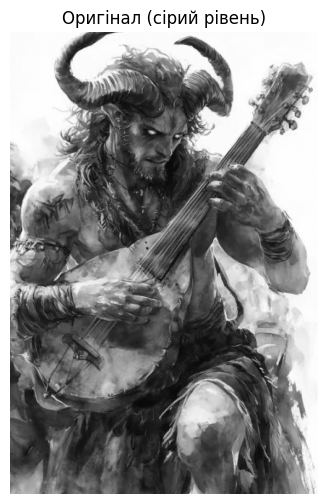

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_01\results\original_gray.png


In [3]:
img = imread_gray_unicode(IMAGE)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title("Оригінал (сірий рівень)")
plt.axis("off")
plt.show()

imwrite_unicode(RESULTS / "original_gray.png", img)
print("Збережено:", RESULTS / "original_gray.png")


## Крок 4. Негатив (інверсія яскравості)

Формула: \( g = 255 - f \) для кожного пікселя.


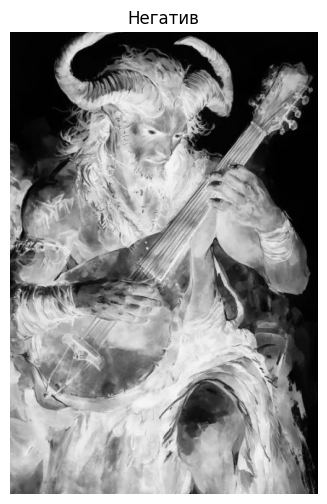

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_01\results\negative.png


In [4]:
img_neg = 255 - img

plt.figure(figsize=(6, 6))
plt.imshow(img_neg, cmap="gray")
plt.title("Негатив")
plt.axis("off")
plt.show()

imwrite_unicode(RESULTS / "negative.png", img_neg)
print("Збережено:", RESULTS / "negative.png")


## Крок 5. Лінійне контрастування

Розтягування динамічного діапазону на \([0, 255]\) через `cv2.normalize` з `NORM_MINMAX`.


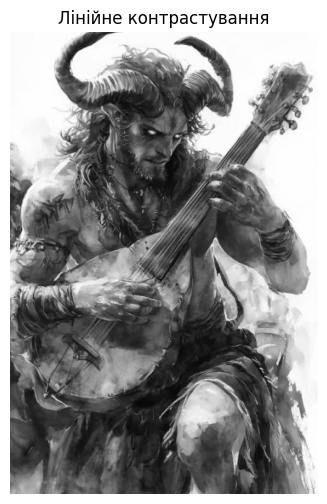

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_01\results\contrast.png


In [5]:
img_contrast = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

plt.figure(figsize=(6, 6))
plt.imshow(img_contrast, cmap="gray")
plt.title("Лінійне контрастування")
plt.axis("off")
plt.show()

imwrite_unicode(RESULTS / "contrast.png", img_contrast)
print("Збережено:", RESULTS / "contrast.png")


## Крок 6. Гістограма яскравості оригіналу

Обчислення `cv2.calcHist`, візуалізація та збереження графіка у `histogram.png`.


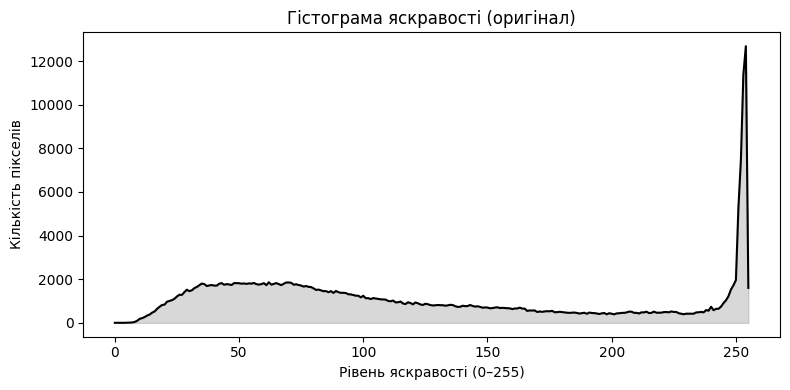

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_01\results\histogram.png
Готово. Перевірте файли у папці results/


In [6]:
hist = cv2.calcHist([img], [0], None, [256], [0, 256])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist, color="black")
ax.fill_between(np.arange(256), hist.flatten(), color="gray", alpha=0.3)
ax.set_title("Гістограма яскравості (оригінал)")
ax.set_xlabel("Рівень яскравості (0–255)")
ax.set_ylabel("Кількість пікселів")
fig.tight_layout()
plt.show()

fig.savefig(RESULTS / "histogram.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Збережено:", RESULTS / "histogram.png")
print("Готово. Перевірте файли у папці results/")
